🌟 **Mini-Project: Data Analysis for Marketing Strategy**

I use the US Superstore dataset to compare markets, identify valuable customers, and decide where marketing should focus.

Data: `US Superstore data.xls`, sheet `Orders`. Keep the file beside this notebook and run the cells from top to bottom. Required packages: pandas, numpy, matplotlib and xlrd. If needed, install them with `%pip install pandas numpy matplotlib xlrd` in a separate cell.

Assignment: [Mini-Project: Marketing Strategy](https://octopus.developers.institute/courses/collection/229/course/812/section/1712/chapter/4006). All amounts are in US dollars. Each row represents an order line, and the analysis covers the full period in the supplied file.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.ticker import PercentFormatter, StrMethodFormatter
from IPython.display import display

pd.options.display.float_format = "{:,.2f}".format

**🌟 1. Load and Preprocess the Dataset**

I inspect missing values, data types and duplicates before calculating totals. Repeated order IDs are expected because one order can include several products.

In [2]:
df = pd.read_excel("US Superstore data.xls", sheet_name="Orders", engine="xlrd")
df.columns = df.columns.str.strip()

print("Original shape:", df.shape)
display(df.head())
df.info()
print("Missing values:")
print(df.isna().sum())
print("Exact duplicate rows:", df.duplicated().sum())

Original shape: (9994, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.00,41.91
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.00,219.58
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.00,6.87
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.58,5,0.45,-383.03
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.37,2,0.20,2.52


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

In [3]:
# Clean text and data types without replacing business values.
for column in df.select_dtypes(include=["object", "string"]).columns:
    df[column] = df[column].str.strip().replace("", pd.NA)

rows_before = len(df)
df = df.drop_duplicates().copy()
print("Exact duplicates removed:", rows_before - len(df))

for column in ["Order Date", "Ship Date"]:
    df[column] = pd.to_datetime(df[column], errors="coerce")
for column in ["Sales", "Profit", "Quantity", "Discount"]:
    df[column] = pd.to_numeric(df[column], errors="coerce").replace([np.inf, -np.inf], np.nan)

# Postal codes are identifiers. Restore leading zeros for US ZIP codes.
df["Postal Code"] = df["Postal Code"].astype("Int64").astype("string").str.zfill(5)
required = ["Row ID", "Order ID", "Order Date", "Customer ID", "Customer Name",
            "State", "City", "Sales", "Profit"]
missing_required = df[required].isna().any(axis=1)
print("Rows excluded for missing required fields:", missing_required.sum())
df = df.loc[~missing_required].copy()

print("Repeated Row IDs:", df["Row ID"].duplicated().sum())
print("Non-positive sales:", (df["Sales"] <= 0).sum())
print("Invalid discounts:", (~df["Discount"].between(0, 1)).sum())
print("Ship dates before order dates:", (df["Ship Date"] < df["Order Date"]).sum())
print("Date range:", df["Order Date"].min().date(), "to", df["Order Date"].max().date())
print("Rows retained:", len(df))
assert df["Row ID"].is_unique, "Investigate repeated Row IDs before aggregating."
assert (df["Sales"] > 0).all(), "Investigate non-positive sales before analysis."

total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
print(f"Total sales: ${total_sales:,.2f}")
print(f"Total profit: ${total_profit:,.2f}")
print(f"Overall profit margin: {total_profit / total_sales:.2%}")

Exact duplicates removed: 0
Rows excluded for missing required fields: 0
Repeated Row IDs: 0
Non-positive sales: 0
Invalid discounts: 0
Ship dates before order dates: 0
Date range: 2014-01-03 to 2017-12-30
Rows retained: 9994
Total sales: $2,297,200.86
Total profit: $286,397.02
Overall profit margin: 12.47%


All 9,994 rows are retained. The supplied data has no missing values or exact duplicates. I keep negative profits and unusually large transactions because these are relevant business outcomes.

Profit margin means total profit divided by total sales. I calculate this from group totals rather than averaging individual row margins.

**🌟 2. Which States Have the Most Sales?**

,Sales,Profit,Orders,Customers,Profit Margin (%)
State,,,,,
California,"457,687.63","76,381.39",1021,577,16.69
New York,"310,876.27","74,038.55",562,415,23.82
Texas,"170,188.05","-25,729.36",487,370,-15.12
Washington,"138,641.27","33,402.65",256,224,24.09
Pennsylvania,"116,511.91","-15,559.96",288,257,-13.35
Florida,"89,473.71","-3,399.30",200,181,-3.80
Illinois,"80,166.10","-12,607.89",276,237,-15.73
Ohio,"78,258.14","-16,971.38",236,202,-21.69
Michigan,"76,269.61","24,463.19",117,106,32.07


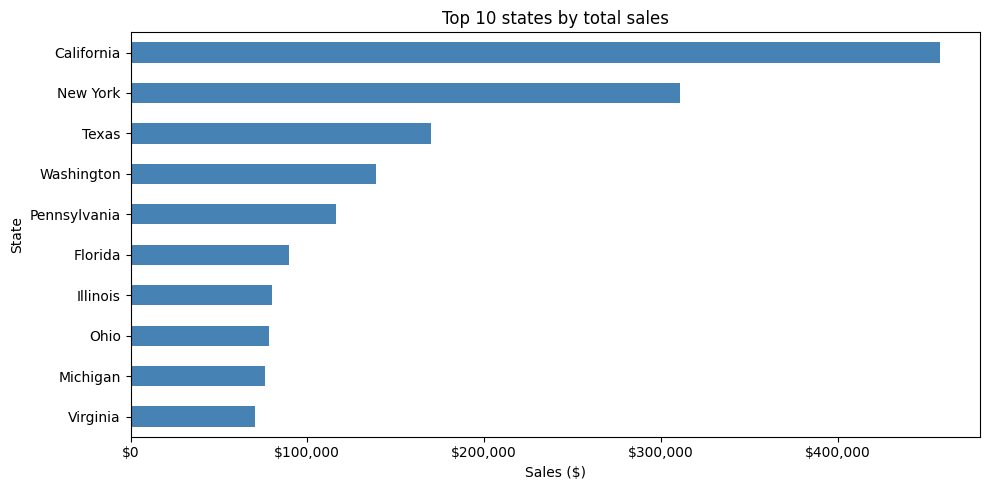

In [4]:
state_summary = df.groupby("State").agg(
    Sales=("Sales", "sum"), Profit=("Profit", "sum"),
    Orders=("Order ID", "nunique"), Customers=("Customer ID", "nunique")
)
state_summary["Profit Margin (%)"] = state_summary["Profit"] / state_summary["Sales"] * 100
top_states = state_summary.sort_values("Sales", ascending=False).head(10)
display(top_states)

fig, ax = plt.subplots(figsize=(10, 5))
top_states["Sales"].sort_values().plot.barh(ax=ax, color="steelblue")
ax.set_title("Top 10 states by total sales")
ax.set_xlabel("Sales ($)")
ax.xaxis.set_major_formatter(StrMethodFormatter("${x:,.0f}"))
plt.tight_layout()
plt.show()

California leads with $457,687.63 in sales, followed by New York ($310,876.27) and Texas ($170,188.05). Texas has high sales but loses money overall, so sales alone cannot determine marketing priorities.

**🌟 3. New York and California: Sales and Profit**

,Sales,Profit,Orders,Customers,Profit Margin (%)
State,,,,,
New York,"310,876.27","74,038.55",562,415,23.82
California,"457,687.63","76,381.39",1021,577,16.69


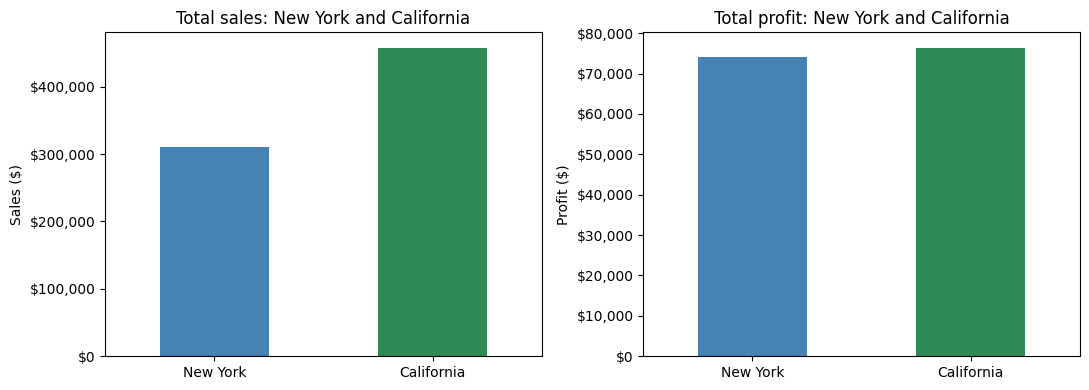

California minus New York sales: $146,811.36
California minus New York profit: $2,342.84


In [5]:
comparison = state_summary.loc[["New York", "California"]]
display(comparison)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, metric in zip(axes, ["Sales", "Profit"]):
    comparison[metric].plot.bar(ax=ax, color=["steelblue", "seagreen"], rot=0)
    ax.set_title(f"Total {metric.lower()}: New York and California")
    ax.set_xlabel("")
    ax.set_ylabel(f"{metric} ($)")
    ax.yaxis.set_major_formatter(StrMethodFormatter("${x:,.0f}"))
plt.tight_layout()
plt.show()

sales_gap = comparison.loc["California", "Sales"] - comparison.loc["New York", "Sales"]
profit_gap = comparison.loc["California", "Profit"] - comparison.loc["New York", "Profit"]
print(f"California minus New York sales: ${sales_gap:,.2f}")
print(f"California minus New York profit: ${profit_gap:,.2f}")

California generates $146,811.36 more sales but only $2,342.84 more profit. New York's margin is 23.82%, compared with California's 16.69%. Both are attractive markets, and New York converts a larger share of sales into profit.

**🌟 4. Who Is an Outstanding Customer in New York?**

I define an outstanding customer as the customer contributing the most total profit from New York orders. This filter refers to the state on the transactions, not a verified customer home address. I also compare sales.

,Customer_Name,Sales,Profit,Orders
Customer ID,,,,
TA-21385,Tom Ashbrook,"13,723.50","4,599.21",2
KD-16495,Keith Dawkins,"5,854.19","2,510.89",2
KD-16270,Karen Daniels,"6,241.28","2,283.05",2
NM-18445,Nathan Mautz,"4,821.29","2,247.19",2
TB-21400,Tom Boeckenhauer,"6,999.96","2,239.99",1
SR-20740,Steven Roelle,"3,904.68","1,863.96",3
PK-19075,Pete Kriz,"4,816.69","1,695.32",2
DM-13015,Darrin Martin,"4,283.79","1,599.68",1
TS-21370,Todd Sumrall,"6,492.31","1,574.97",2


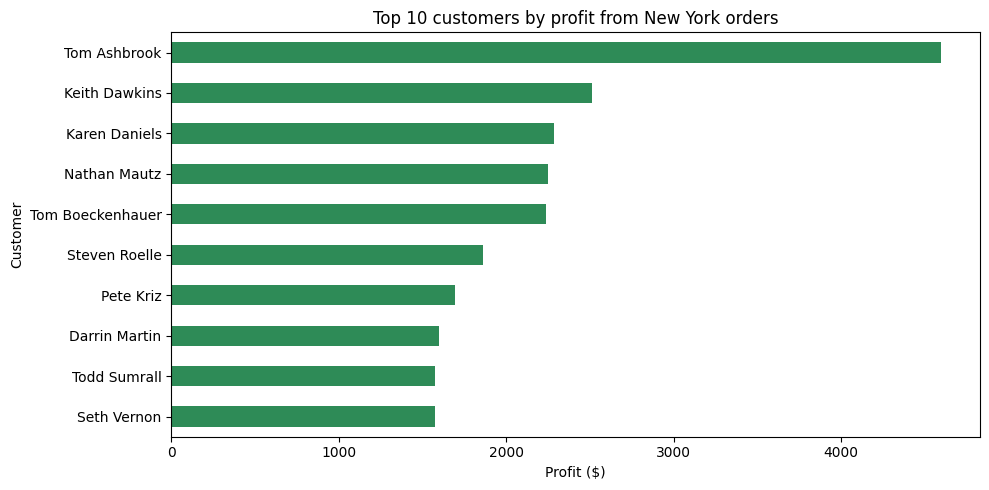

,Customer_Name,Sales,Profit,Orders
Customer ID,,,,
TA-21385,Tom Ashbrook,"13,723.50","4,599.21",2


In [6]:
ny_customers = df.loc[df["State"] == "New York"].groupby("Customer ID").agg(
    Customer_Name=("Customer Name", "first"), Sales=("Sales", "sum"),
    Profit=("Profit", "sum"), Orders=("Order ID", "nunique")
).sort_values("Profit", ascending=False)
display(ny_customers.head(10))

fig, ax = plt.subplots(figsize=(10, 5))
ny_customers.head(10).sort_values("Profit").plot.barh(
    x="Customer_Name", y="Profit", ax=ax, legend=False, color="seagreen"
)
ax.set_title("Top 10 customers by profit from New York orders")
ax.set_xlabel("Profit ($)")
ax.set_ylabel("Customer")
plt.tight_layout()
plt.show()
display(ny_customers.sort_values("Sales", ascending=False).head(1))

Tom Ashbrook is the outstanding New York customer by profit, contributing $4,599.21 from $13,723.50 in sales. He also ranks first by New York sales. A retention offer should preserve this profitability rather than rely on a large discount.

**🌟 5. Are There Differences Among States in Profitability?**

I compare both total profit and profit margin. Total profit measures contribution, while margin measures profit per dollar of sales.

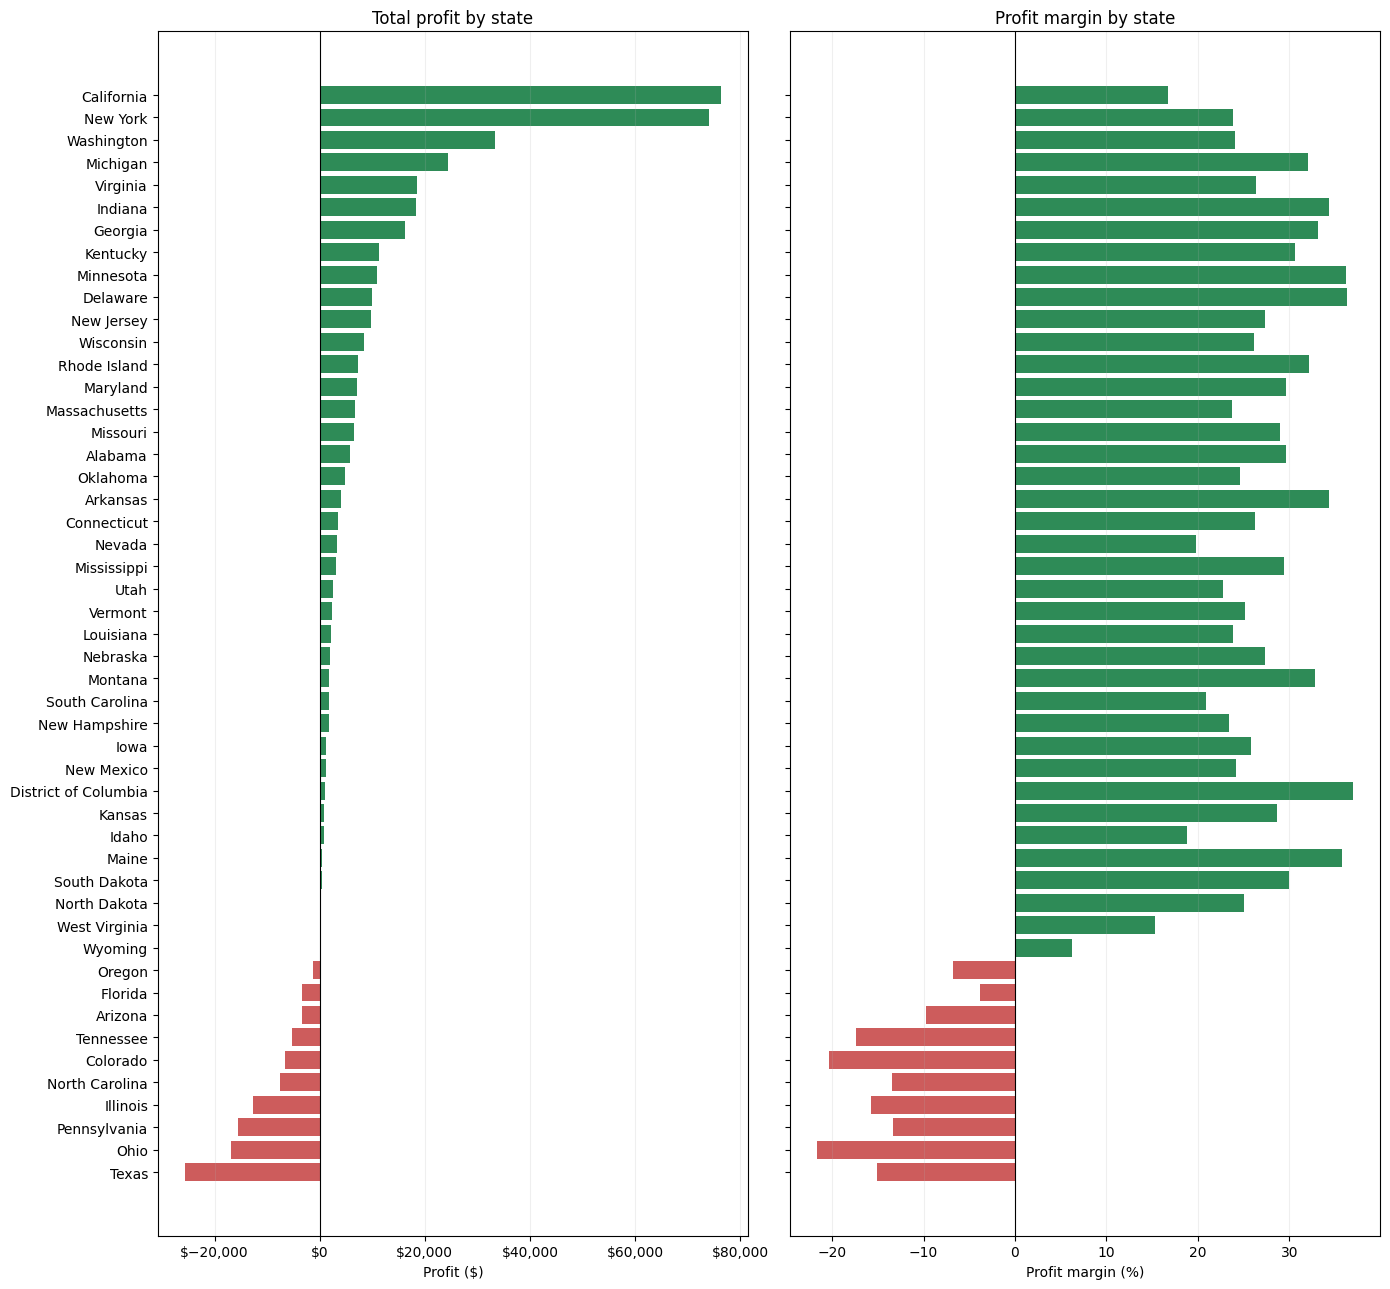

,Sales,Profit,Orders,Customers,Profit Margin (%)
State,,,,,
Texas,"170,188.05","-25,729.36",487,370,-15.12
Ohio,"78,258.14","-16,971.38",236,202,-21.69
Pennsylvania,"116,511.91","-15,559.96",288,257,-13.35
Illinois,"80,166.10","-12,607.89",276,237,-15.73
North Carolina,"55,603.16","-7,490.91",136,122,-13.47
Colorado,"32,108.12","-6,527.86",79,75,-20.33
Tennessee,"30,661.87","-5,341.69",91,84,-17.42
Arizona,"35,282.00","-3,427.92",108,100,-9.72
Florida,"89,473.71","-3,399.30",200,181,-3.80


In [7]:
ranked_states = state_summary.sort_values("Profit")
colors = np.where(ranked_states["Profit"] >= 0, "seagreen", "indianred")
fig, axes = plt.subplots(1, 2, figsize=(14, 13), sharey=True)
axes[0].barh(ranked_states.index, ranked_states["Profit"], color=colors)
axes[1].barh(ranked_states.index, ranked_states["Profit Margin (%)"], color=colors)
axes[0].set_title("Total profit by state")
axes[0].set_xlabel("Profit ($)")
axes[0].xaxis.set_major_formatter(StrMethodFormatter("${x:,.0f}"))
axes[1].set_title("Profit margin by state")
axes[1].set_xlabel("Profit margin (%)")
for ax in axes:
    ax.axvline(0, color="black", linewidth=0.8)
    ax.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.show()
display(state_summary.sort_values("Profit").head(10))

California and New York have the largest total profits. Washington is also strong, with $33,402.65 profit and a 24.09% margin. Texas loses $25,729.36, Ohio loses $16,971.38, and Pennsylvania loses $15,559.96.

I would investigate product mix and discount patterns in loss-making states before increasing acquisition spending. These comparisons show where losses occur, but do not establish their causes.

**🌟 6. Can We Apply the Pareto Principle to Customers and Profit?**

I aggregate by Customer ID and rank customers by total profit, highest first. The top 20% uses `ceil(0.20 × number of customers)` so it includes a whole customer. The denominator is total net profit, including losses. I also find the smallest leading group reaching 80% of net profit.

Customers: 793
Top group: 159 customers (20.05%)
Top group share of net profit: 81.66%
Customers needed for 80% of net profit: 153 (19.29%)
Customers with negative total profit: 155


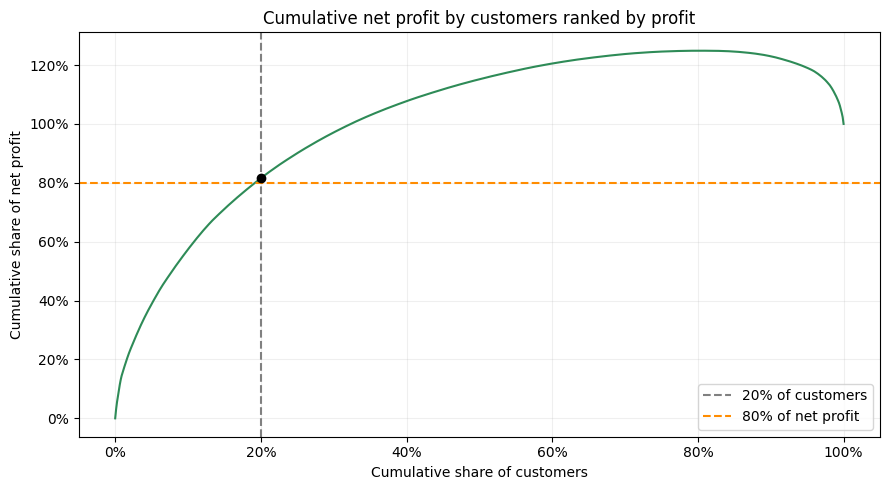

In [8]:
customers = df.groupby("Customer ID").agg(
    Customer_Name=("Customer Name", "first"), Sales=("Sales", "sum"),
    Profit=("Profit", "sum"), Orders=("Order ID", "nunique")
)
customer_count = len(customers)
top_20_count = int(np.ceil(customer_count * 0.20))
profit_rank = customers.sort_values("Profit", ascending=False).copy()
profit_rank["Customer Share"] = np.arange(1, customer_count + 1) / customer_count
profit_rank["Cumulative Profit Share"] = profit_rank["Profit"].cumsum() / total_profit
top_profit_share = profit_rank.head(top_20_count)["Profit"].sum() / total_profit
profit_80_count = np.flatnonzero(profit_rank["Cumulative Profit Share"].to_numpy() >= 0.80)[0] + 1

print("Customers:", customer_count)
print(f"Top group: {top_20_count} customers ({top_20_count / customer_count:.2%})")
print(f"Top group share of net profit: {top_profit_share:.2%}")
print(f"Customers needed for 80% of net profit: {profit_80_count} ({profit_80_count / customer_count:.2%})")
print("Customers with negative total profit:", (customers["Profit"] < 0).sum())

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(np.r_[0, profit_rank["Customer Share"]],
        np.r_[0, profit_rank["Cumulative Profit Share"]], color="seagreen")
ax.axvline(0.20, color="gray", linestyle="--", label="20% of customers")
ax.axhline(0.80, color="darkorange", linestyle="--", label="80% of net profit")
ax.scatter(top_20_count / customer_count, top_profit_share, color="black", zorder=3)
ax.set(title="Cumulative net profit by customers ranked by profit",
       xlabel="Cumulative share of customers", ylabel="Cumulative share of net profit")
ax.xaxis.set_major_formatter(PercentFormatter(1))
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

The top 159 of 793 customers (20.05%) contribute **81.66% of net profit**. The first 153 customers (19.29%) reach 80%. Profit is strongly concentrated, so the 80/20 principle is a useful approximate guide, although the observed share is not exactly 80%.

The curve rises above 100% before returning to 100% because loss-making customers are added last. This is a share of net profit, not a nonnegative probability distribution. Removing unprofitable customers from the denominator would answer a different question.

**🌟 7. Top 20 Cities by Sales and by Profit**

I group by both State and City so different places with the same city name are not combined. I compare the rankings and the margins of the leading markets.

Top 20 cities by sales:


,,Sales,Profit,Orders,Profit Margin (%),Sales Rank,Profit Rank
State,City,,,,,,
New York,New York City,"256,368.16","62,036.98",450,24.20,1,1
California,Los Angeles,"175,851.34","30,440.76",384,17.31,2,2
Washington,Seattle,"119,540.74","29,156.10",212,24.39,3,3
California,San Francisco,"112,669.09","17,507.39",265,15.54,4,4
Pennsylvania,Philadelphia,"109,077.01","-13,837.77",265,-12.69,5,604
Texas,Houston,"64,504.76","-10,153.55",188,-15.74,6,603
Illinois,Chicago,"48,539.54","-6,654.57",171,-13.71,7,600
California,San Diego,"47,521.03","6,377.20",88,13.42,8,10
Michigan,Detroit,"42,446.94","13,181.79",53,31.05,9,5


Top 20 cities by profit:


,,Sales,Profit,Orders,Profit Margin (%),Sales Rank,Profit Rank
State,City,,,,,,
New York,New York City,"256,368.16","62,036.98",450,24.20,1,1
California,Los Angeles,"175,851.34","30,440.76",384,17.31,2,2
Washington,Seattle,"119,540.74","29,156.10",212,24.39,3,3
California,San Francisco,"112,669.09","17,507.39",265,15.54,4,4
Michigan,Detroit,"42,446.94","13,181.79",53,31.05,9,5
Indiana,Lafayette,"19,630.45","8,976.10",7,45.73,14,6
Delaware,Newark,"20,448.05","8,086.17",29,39.54,12,7
Georgia,Atlanta,"17,197.84","6,993.66",17,40.67,15,8
Minnesota,Minneapolis,"16,870.54","6,824.58",13,40.45,16,9


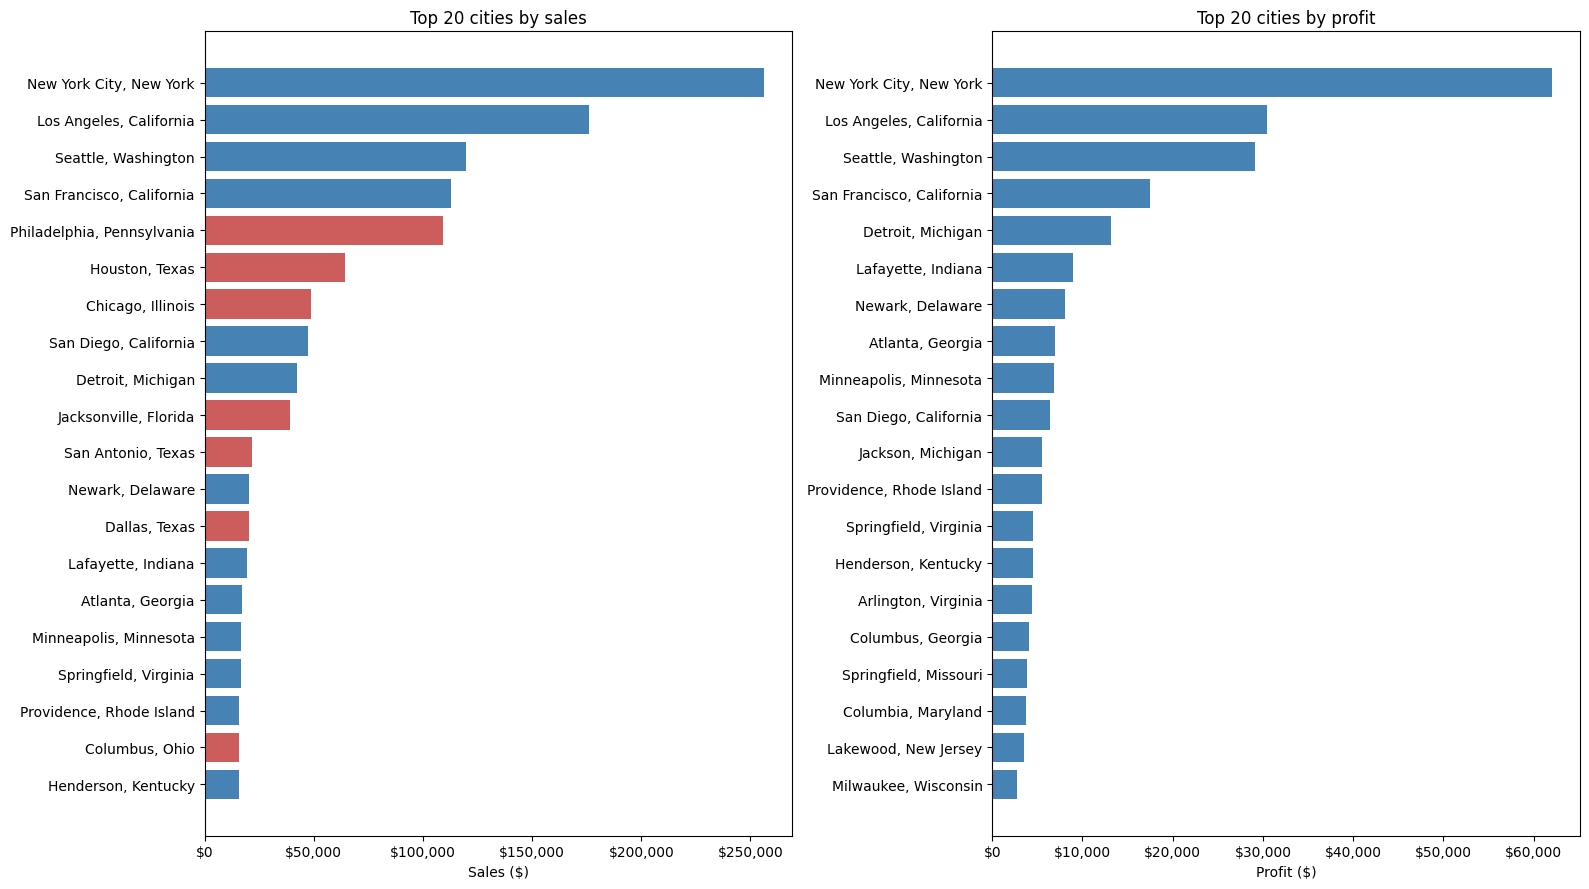

Cities in both top-20 lists: 13
Loss-making cities in the top 20 by sales:


Sales     Profit  Orders  Profit Margin (%)  \
State        City                                                            
Pennsylvania Philadelphia 109,077.01 -13,837.77     265             -12.69   
Texas        Houston       64,504.76 -10,153.55     188             -15.74   
Illinois     Chicago       48,539.54  -6,654.57     171             -13.71   
Florida      Jacksonville  39,133.33  -2,445.66      38              -6.25   
Texas        San Antonio   21,843.53  -7,299.05      27             -33.42   
             Dallas        20,131.93  -2,846.53      80             -14.14   
Ohio         Columbus      15,900.79    -729.51      55              -4.59   

                           Sales Rank  Profit Rank  
State        City                                   
Pennsylvania Philadelphia           5          604  
Texas        Houston                6          603  
Illinois     Chicago                7          600  
Florida      Jacksonville          10          595  
Texas        San Antonio           11          602  
             Dallas                13          597  
Ohio         Columbus              19          574

In [9]:
city_summary = df.groupby(["State", "City"]).agg(
    Sales=("Sales", "sum"), Profit=("Profit", "sum"), Orders=("Order ID", "nunique")
)
city_summary["Profit Margin (%)"] = city_summary["Profit"] / city_summary["Sales"] * 100
city_summary["Sales Rank"] = city_summary["Sales"].rank(ascending=False, method="min").astype(int)
city_summary["Profit Rank"] = city_summary["Profit"].rank(ascending=False, method="min").astype(int)
top_cities_sales = city_summary.sort_values("Sales", ascending=False).head(20)
top_cities_profit = city_summary.sort_values("Profit", ascending=False).head(20)
print("Top 20 cities by sales:")
display(top_cities_sales)
print("Top 20 cities by profit:")
display(top_cities_profit)

fig, axes = plt.subplots(1, 2, figsize=(16, 9))
for ax, table, metric in zip(axes, [top_cities_sales, top_cities_profit], ["Sales", "Profit"]):
    chart = table.sort_values(metric)
    labels = [f"{city}, {state}" for state, city in chart.index]
    colors = np.where(chart["Profit"] >= 0, "steelblue", "indianred")
    ax.barh(labels, chart[metric], color=colors)
    ax.set_title(f"Top 20 cities by {metric.lower()}")
    ax.set_xlabel(f"{metric} ($)")
    ax.xaxis.set_major_formatter(StrMethodFormatter("${x:,.0f}"))
plt.tight_layout()
plt.show()

overlap = top_cities_sales.index.intersection(top_cities_profit.index)
print("Cities in both top-20 lists:", len(overlap))
print("Loss-making cities in the top 20 by sales:")
display(top_cities_sales.loc[top_cities_sales["Profit"] < 0])

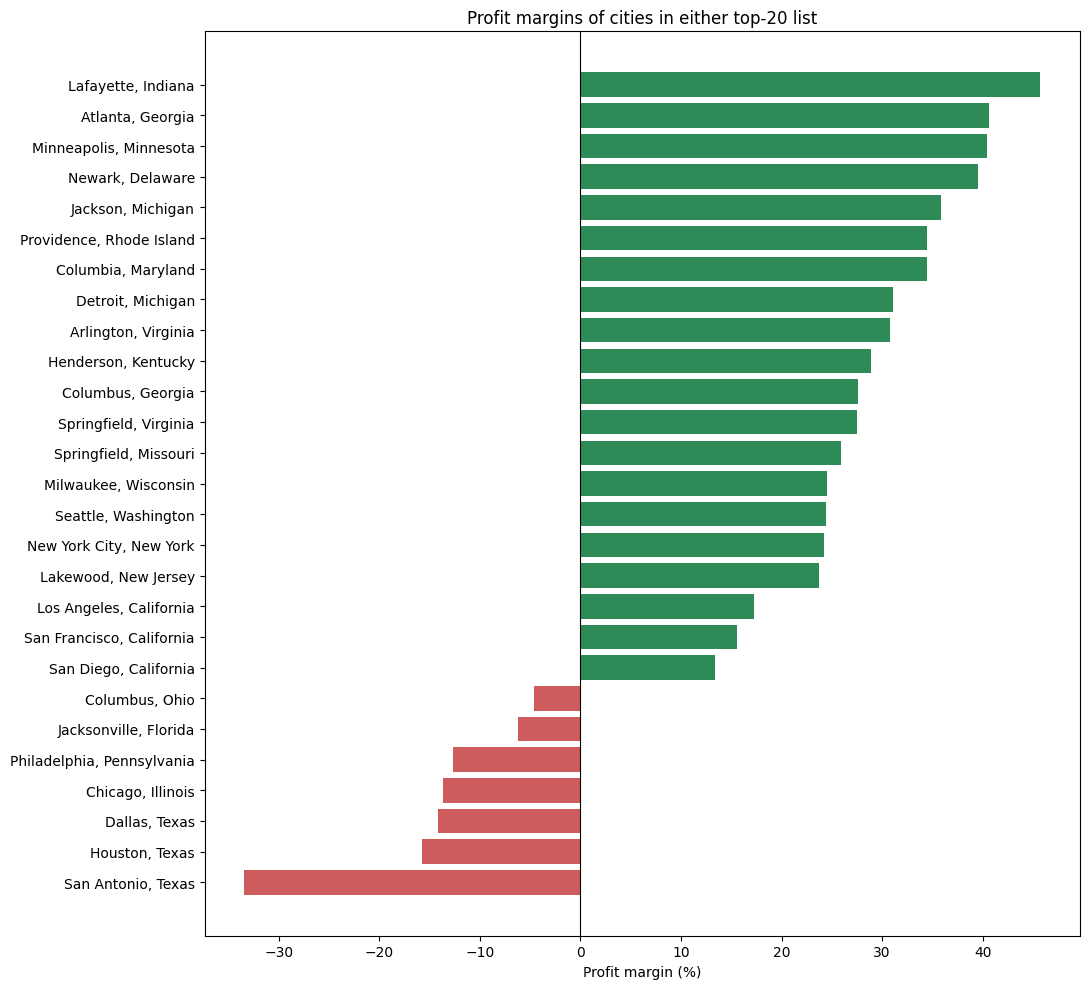

In [10]:
# Compare margins across the union of the two top-20 lists.
leading_cities = city_summary.loc[top_cities_sales.index.union(top_cities_profit.index)]
margin_order = leading_cities.sort_values("Profit Margin (%)")
labels = [f"{city}, {state}" for state, city in margin_order.index]
fig, ax = plt.subplots(figsize=(11, 10))
ax.barh(labels, margin_order["Profit Margin (%)"],
        color=np.where(margin_order["Profit"] >= 0, "seagreen", "indianred"))
ax.axvline(0, color="black", linewidth=0.8)
ax.set(title="Profit margins of cities in either top-20 list", xlabel="Profit margin (%)")
plt.tight_layout()
plt.show()

New York City leads both rankings, with $256,368.16 sales and $62,036.98 profit. Los Angeles and Seattle are also major profitable markets. San Francisco produces $17,507.39 profit, while Detroit contributes $13,181.79 despite lower sales.

High sales do not guarantee profitability. Philadelphia and Houston are prominent sales markets with negative profit. Red bars identify loss-making markets. I would prioritize profitable cities and investigate the losses before expanding promotions in these markets.

**🌟 8. Top 20 Customers by Sales**

,Customer_Name,Sales,Profit,Orders
Customer ID,,,,
SM-20320,Sean Miller,"25,043.05","-1,980.74",5
TC-20980,Tamara Chand,"19,052.22","8,981.32",5
RB-19360,Raymond Buch,"15,117.34","6,976.10",6
TA-21385,Tom Ashbrook,"14,595.62","4,703.79",4
AB-10105,Adrian Barton,"14,473.57","5,444.81",10
KL-16645,Ken Lonsdale,"14,175.23",806.85,12
SC-20095,Sanjit Chand,"14,142.33","5,757.41",9
HL-15040,Hunter Lopez,"12,873.30","5,622.43",6
SE-20110,Sanjit Engle,"12,209.44","2,650.68",11


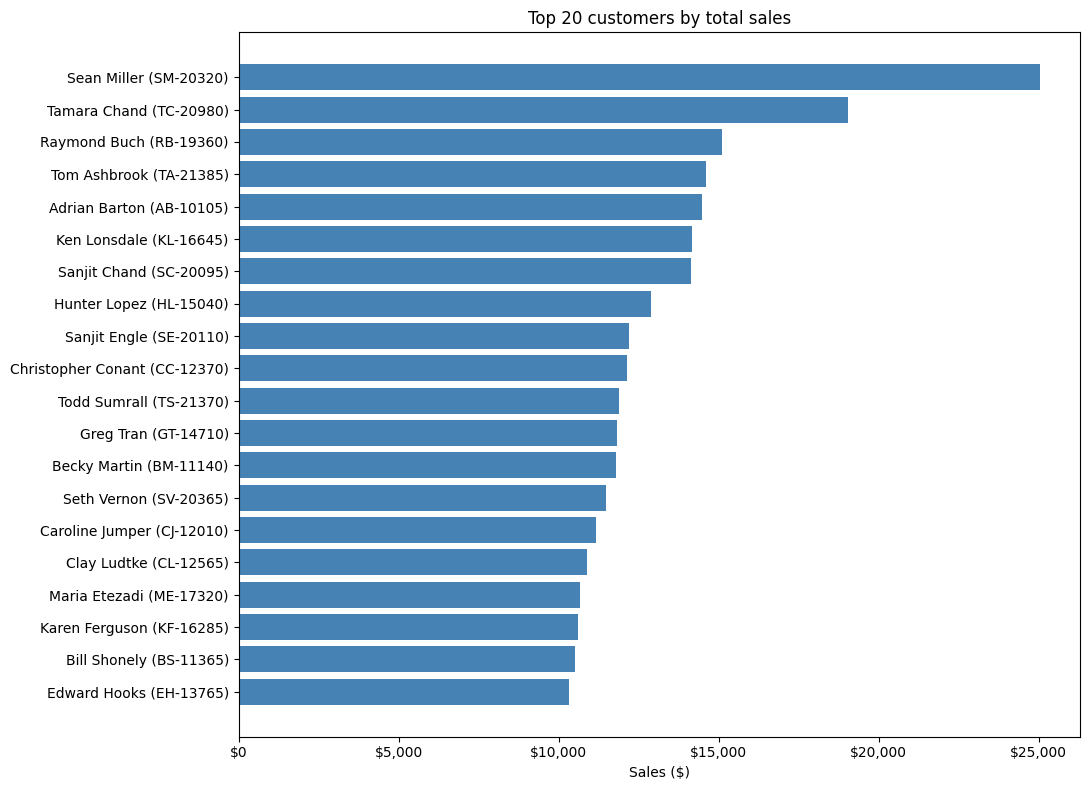

In [11]:
top_customers_sales = customers.sort_values("Sales", ascending=False).head(20)
display(top_customers_sales)
chart = top_customers_sales.sort_values("Sales")
fig, ax = plt.subplots(figsize=(11, 8))
labels = chart["Customer_Name"] + " (" + chart.index + ")"
ax.barh(labels, chart["Sales"], color="steelblue")
ax.set(title="Top 20 customers by total sales", xlabel="Sales ($)")
ax.xaxis.set_major_formatter(StrMethodFormatter("${x:,.0f}"))
plt.tight_layout()
plt.show()

Sean Miller ranks first with $25,043.05 in sales. I include profit alongside sales in the table because a high-spending customer can still produce a loss. Sales leaders are candidates for retention after reviewing their profit contribution.

**🌟 9. Cumulative Sales by Customers and the Pareto Principle**

For this question, I rank customers by sales rather than profit. The cumulative curve measures the share of total sales generated by the highest-spending customers.

Top 159 customers' share of sales: 48.15%
Customers needed for 80% of sales: 396 (49.94%)


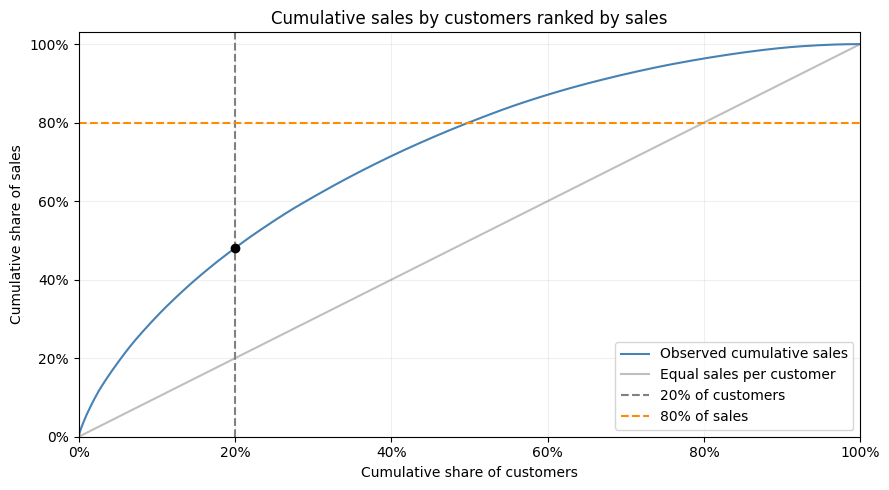

In [12]:
sales_rank = customers.sort_values("Sales", ascending=False).copy()
sales_rank["Customer Share"] = np.arange(1, customer_count + 1) / customer_count
sales_rank["Cumulative Sales Share"] = sales_rank["Sales"].cumsum() / total_sales
top_sales_share = sales_rank.head(top_20_count)["Sales"].sum() / total_sales
sales_80_count = np.flatnonzero(sales_rank["Cumulative Sales Share"].to_numpy() >= 0.80)[0] + 1

print(f"Top {top_20_count} customers' share of sales: {top_sales_share:.2%}")
print(f"Customers needed for 80% of sales: {sales_80_count} ({sales_80_count / customer_count:.2%})")
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(np.r_[0, sales_rank["Customer Share"]], np.r_[0, sales_rank["Cumulative Sales Share"]],
        color="steelblue", label="Observed cumulative sales")
ax.plot([0, 1], [0, 1], color="gray", alpha=0.5, label="Equal sales per customer")
ax.axvline(0.20, color="gray", linestyle="--", label="20% of customers")
ax.axhline(0.80, color="darkorange", linestyle="--", label="80% of sales")
ax.scatter(top_20_count / customer_count, top_sales_share, color="black", zorder=3)
ax.set(title="Cumulative sales by customers ranked by sales",
       xlabel="Cumulative share of customers", ylabel="Cumulative share of sales", xlim=(0, 1), ylim=(0, 1.03))
ax.xaxis.set_major_formatter(PercentFormatter(1))
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.legend(loc="lower right")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

The top 159 customers generate **48.15% of sales**, well below 80%. It takes 396 customers (49.94%) to reach 80% of sales. The 80/20 rule does not fit customer sales in this dataset. Sales are spread across a broader customer base than net profit.

**🌟 10. Marketing Recommendations**

| Priority | States and cities | Decision based on the analysis |
|---|---|---|
| Focus acquisition and retention | New York, especially New York City; California, especially Los Angeles and San Francisco | These markets combine large sales with strong total profit. New York has the higher state margin. |
| Test additional growth | Washington, especially Seattle; Michigan, especially Detroit | Both contribute substantial profit. Start with measured campaigns and expand if incremental profit remains positive. |
| Review losses before expansion | Texas, especially Houston; Pennsylvania, especially Philadelphia; Ohio and Illinois | High sales in some of these markets coexist with losses. Review product mix, discounts and order economics before increasing spend. |
| Retain profitable customers | The highest-profit customers nationally, and Tom Ashbrook for New York orders | Profit is concentrated. Use targeted service and relevant offers, and track profit after the cost of the offer. |

I would evaluate campaigns using incremental profit after marketing costs, alongside sales and repeat purchases. Historical profit identifies candidates for a campaign, but the dataset contains no campaign spend or response data, so it cannot establish marketing ROI or an optimal budget. Small tests with a comparison group would help decide where to scale.

In [13]:
# Reconcile the grouped results with the cleaned source data.
for summary in [state_summary, city_summary, customers]:
    assert np.isclose(summary["Sales"].sum(), total_sales)
    assert np.isclose(summary["Profit"].sum(), total_profit)
assert np.isclose(sales_rank["Cumulative Sales Share"].iloc[-1], 1)
assert np.isclose(profit_rank["Cumulative Profit Share"].iloc[-1], 1)
print("State, city and customer totals match the cleaned dataset.")

State, city and customer totals match the cleaned dataset.
